# HCIA-AI Study Assistant: Indexing & RAG Pipeline

This notebook **builds everything the app needs**:

| Part | What it does | Output |
|---|---|---|
| 1. EDA | Checks text extraction and duplicates in the lecture PDFs | Decisions table + chart |
| 2. Question bank | Converts the Word question bank to structured data | `question_bank.json` |
| 3. Pages → chunks | One slide = one chunk, cleaned, empty + duplicate pages removed | `pages.json` |
| 4. Index | Dense embeddings + ChromaDB with metadata (lecture, page) | `rag_db/` |
| 5. Retrieval | Hybrid search (dense + TF-IDF) | test results |
| 6. Generation | Grounded explanation with slide citations | test answers |
| 7. Quiz | MCQs generated from the retrieved slides (JSON), validated and graded | test quiz |
| 8. Evaluation | Hit@3 on 24 hand-labeled questions for different alpha values | table + chart |
| 9. Bank evaluation | RAG answers the answered HCIA bank: correct / wrong / not in lectures | `bank_eval_results.json` + chart |

The app (`app.py`) only **reads** `rag_db/` and `question_bank.json`.
Sections 6, 7 and 9 call the OpenAI API (key in `.env`).

**Project folder layout**
```
HCIA-AI-RAG-System/
├── Study_Assistant_Pipeline.ipynb
├── app.py                  ← Streamlit app
├── assets/                 ← app theme + character, and the evaluation charts
├── .streamlit/config.toml  ← light theme, file watcher off
├── .env                    ← OPENAI_API_KEY=...  (not on GitHub)
├── question_bank.docx
├── question_bank.json      ← generated by Section 2
├── question_bank_answer_key.docx ← same bank with answers (Section 9)
├── bank_eval_results.json  ← generated by Section 9
├── pages.json              ← generated by Section 3
├── rag_db/                 ← generated by Section 4
├── agentic_chunks.json     ← output of the Appendix experiment
├── lectures/               ← PDFs we index
└── excluded/               ← PDFs we checked and decided NOT to index
```

## 0. Setup

In [1]:
# Run once if a library is missing
# %pip install pypdf python-docx langchain-openai python-dotenv sentence-transformers chromadb scikit-learn pandas matplotlib streamlit

In [2]:
import os
import re
import json
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import chromadb
from docx import Document
from dotenv import load_dotenv
from pypdf import PdfReader
from langchain_openai import ChatOpenAI
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import TfidfVectorizer

In [3]:
# ---------- Paths (relative → works on any computer after git clone) ----------
BASE_DIR = Path.cwd()          # the folder this notebook is in

LECTURES_DIR = BASE_DIR / "lectures"
EXCLUDED_DIR = BASE_DIR / "excluded"
BANK_DOCX    = BASE_DIR / "question_bank.docx"
BANK_JSON    = BASE_DIR / "question_bank.json"
PAGES_JSON   = BASE_DIR / "pages.json"
DB_PATH      = BASE_DIR / "rag_db"
ENV_PATH     = BASE_DIR / ".env"

# ---------- Settings (must match app.py) ----------
COLLECTION_NAME = "lectures"
MODEL_NAME      = "BAAI/bge-small-en-v1.5"
LLM_NAME        = "gpt-4o-mini"
MIN_CHARS       = 30           # pages shorter than this are treated as empty

# ---------- API key ----------
load_dotenv(ENV_PATH, override=True)
if not os.getenv("OPENAI_API_KEY"):
    raise ValueError(f"OPENAI_API_KEY not found in {ENV_PATH}")

for name, path in [("lectures/", LECTURES_DIR), ("excluded/", EXCLUDED_DIR),
                   ("question bank", BANK_DOCX), (".env", ENV_PATH)]:
    print(f"{name:14} exists: {path.exists()}")

print("\nPDFs to index:", len(list(LECTURES_DIR.glob("*.pdf"))))
print("PDFs excluded:", len(list(EXCLUDED_DIR.glob("*.pdf"))))

lectures/      exists: True
excluded/      exists: True
question bank  exists: True
.env           exists: True

PDFs to index: 22
PDFs excluded: 2


## 1. EDA: can we read the lectures?

Before indexing, we check that `pypdf` actually extracts text from every file.
A slide that is an image returns empty text, and the model would silently know nothing about it.

We check **both** folders, so the table also documents *why* the excluded files were excluded.

In [4]:
def get_pages_text(pdf_path):
    reader = PdfReader(pdf_path)
    pages_text = []
    for page in reader.pages:
        text = page.extract_text() or ""
        pages_text.append(text.strip())
    return pages_text


all_pdfs = []
for pdf_path in sorted(LECTURES_DIR.glob("*.pdf")):
    all_pdfs.append((pdf_path, "indexed"))
for pdf_path in sorted(EXCLUDED_DIR.glob("*.pdf")):
    all_pdfs.append((pdf_path, "excluded"))

rows = []
for pdf_path, status in all_pdfs:
    pages_text = get_pages_text(pdf_path)
    lengths = [len(t) for t in pages_text]
    empty_count = sum(1 for n in lengths if n < MIN_CHARS)

    rows.append({
        "file": pdf_path.stem,
        "status": status,
        "pages": len(pages_text),
        "avg_chars": round(sum(lengths) / len(lengths)),
        "empty_pages": empty_count,
        "empty_%": round(empty_count / len(pages_text) * 100),
    })

eda_df = pd.DataFrame(rows).sort_values("empty_%", ascending=False)
eda_df

,file,status,pages,avg_chars,empty_pages,empty_%
23,Linear_Regression-1 2,excluded,79,0,79,100
3,decision tree & ensemble learning & random forest,indexed,55,245,22,40
19,NLP - Text preprocessing,indexed,64,254,25,39
12,Hierarchical Clustering,indexed,27,94,8,30
4,decision tree & ensemble learning,indexed,107,294,29,27
15,K-means,indexed,37,142,8,22
21,Word Embedding,indexed,36,496,7,19
13,Imbalanced_Data,indexed,19,476,1,5
7,Feature Selection in Machine Learning,indexed,37,642,0,0
6,Exploratory Data Analysis_Nancy Ahmed (2),indexed,45,382,0,0


**Chart:** percentage of pages with no extractable text, per file.
- **X-axis:** % of empty pages
- **Y-axis:** file name
- **Look for:** long bars = content we cannot read as text (images / screenshots).
- **Careful:** an empty page is not always lost content. It can be a title slide or a diagram.
  We opened the flagged files to check (see the decisions table below).

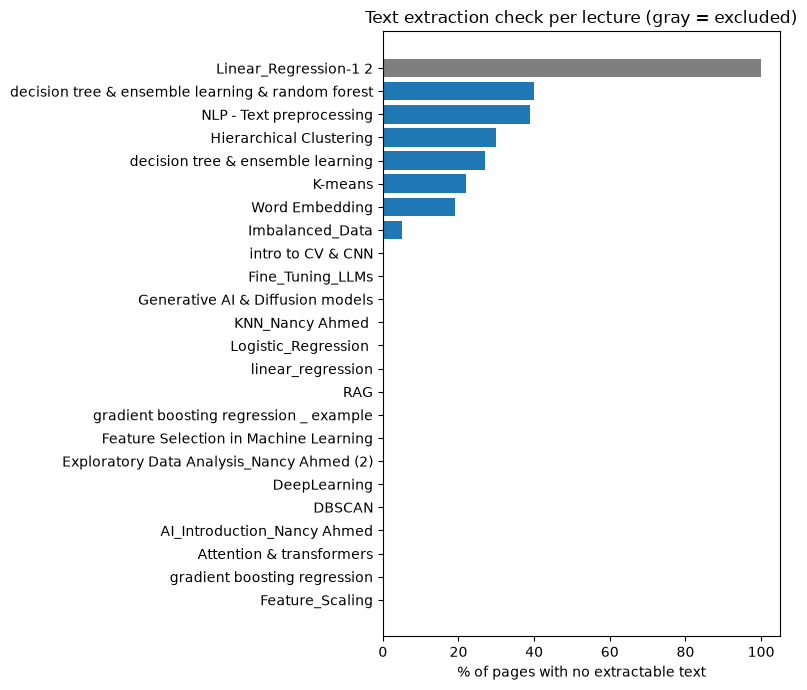

In [5]:
plot_df = eda_df.sort_values("empty_%")
colors = ["tab:gray" if s == "excluded" else "tab:blue" for s in plot_df["status"]]

plt.figure(figsize=(8, 7))
plt.barh(plot_df["file"], plot_df["empty_%"], color=colors)
plt.xlabel("% of pages with no extractable text")
plt.title("Text extraction check per lecture (gray = excluded)")
plt.tight_layout()
plt.show()

### Duplicate check
Two files had the same page count and average length, and two others shared the same empty-page pattern.
Duplicates hurt RAG: with `top_k=3`, two of the three results could be the same slide, and the quiz would repeat questions.

In [6]:
a = get_pages_text(LECTURES_DIR / "gradient boosting regression.pdf")
b = get_pages_text(EXCLUDED_DIR / "gradient boosting regression _ example.pdf")
print("Gradient boosting files identical:", a == b)

small = get_pages_text(LECTURES_DIR / "decision tree & ensemble learning & random forest.pdf")
big = get_pages_text(LECTURES_DIR / "decision tree & ensemble learning.pdf")

big_set = set(big)
non_empty_small = [page for page in small if page]
found = 0
for page in non_empty_small:
    if page in big_set:
        found += 1

print(f"{found} / {len(non_empty_small)} pages of the small decision tree file exist in the big file")

Gradient boosting files identical: True
32 / 43 pages of the small decision tree file exist in the big file


### Decisions from the EDA

| Finding | Decision | Why |
|---|---|---|
| `gradient boosting regression _ example` is 100% identical to `gradient boosting regression` | Moved to `excluded/` | Exact duplicate |
| `Linear_Regression-1 2` has 0 extractable characters (79 pages) | Moved to `excluded/` | Opened it: 60+ pages are graphs used for visual explanation, no real text content. The text version is `linear_regression` |
| Small decision tree file: 32 / 43 pages exist in the big file | Keep **both**, remove duplicate **pages** automatically (Section 3) | The small file has 11 unique pages |
| Hierarchical Clustering, K-means, NLP, Word Embedding have many empty pages | Index the text now; screenshots are a **known limitation** | Opened Hierarchical: most empty pages are screenshots with text inside. Possible fix later: a vision LLM to transcribe them |
| All other files | Index normally | Text extracts correctly |

## 2. Question bank → structured data

The bank is a Word file: section headings (style `Heading 1`), then questions like
`2. [Multiple-Choice — select all that apply] Which ...`, each followed by options `A.` to `D.`.

We convert it to a list of dicts (`question_bank.json`) so the notebook and the app can load it quickly.

The bank is used for two things, **never as quiz content**:
- **Style examples (few-shot)** when generating new quiz questions from the lectures (Section 7.1)
- **Evaluation:** its answer key (a separate Word file) tests our whole pipeline (Section 9)

In [7]:
doc = Document(BANK_DOCX)

questions = []
current_section = None
current_question = None

for paragraph in doc.paragraphs:
    text = paragraph.text.strip()
    if not text:
        continue

    # 1) Section title, e.g. "1. AI Fundamentals & Applications"
    if paragraph.style.name == "Heading 1":
        current_section = re.sub(r"^\d+\.\s*", "", text)
        continue

    # 2) Question line, e.g. "2. [Multiple-Choice — select all that apply] Which of..."
    question_match = re.match(r"^(\d+)\.\s*\[(.+?)\]\s*(.+)$", text)
    if question_match:
        number = int(question_match.group(1))
        type_text = question_match.group(2)
        question_text = question_match.group(3)

        if type_text.startswith("Multiple"):
            q_type = "multiple"
        else:
            q_type = "single"

        current_question = {
            "id": f"bank_{number}",
            "section": current_section,
            "type": q_type,
            "question": question_text,
            "options": {}
        }
        questions.append(current_question)
        continue

    # 3) Option line, e.g. "A. Predictive maintenance of equipment"
    option_match = re.match(r"^([A-F])\.\s*(.+)$", text)
    if option_match and current_question is not None:
        letter = option_match.group(1)
        current_question["options"][letter] = option_match.group(2)


# ---------- Sanity checks (expected: 130 questions, 100 single / 30 multiple, all with 4 options) ----------
print("Total questions:", len(questions))
print("Per type:", Counter(q["type"] for q in questions))
print("Options per question:", Counter(len(q["options"]) for q in questions))
print("\nPer section:")
for section, count in Counter(q["section"] for q in questions).items():
    print(f"  {count:3}  {section}")

with open(BANK_JSON, "w", encoding="utf-8") as f:
    json.dump(questions, f, ensure_ascii=False, indent=2)
print("\nSaved →", BANK_JSON.name)

Total questions: 130
Per type: Counter({'single': 100, 'multiple': 30})
Options per question: Counter({4: 130})

Per section:
   13  AI Fundamentals & Applications
   12  Machine Learning Basics
   15  Neural Networks & Activation Functions
   13  Training, Optimization & Regularization
   12  CNNs & Computer Vision
   12  NLP, Transformer & Attention
   14  Frameworks & Tools
   15  Large Models & Fine-Tuning
   12  Parallel Training
   12  Data Preprocessing & Evaluation

Saved → question_bank.json


## 3. Pages → chunks (page-based chunking)

**Decision: one slide = one chunk.**

| | Agentic chunking (first experiment, see Appendix) | Page-based (chosen) |
|---|---|---|
| Idea | LLM decides which paragraphs belong together | Each slide is one chunk |
| Page number for citations | Lost (pages were joined before splitting) | Kept automatically |
| Cost / time for 22 PDFs | One API call per paragraph | Zero |
| Fits our data? | Better for long continuous text | Slides already hold ~one idea each |

For every page we:
1. **Clean** it (`fix_spaced_letters`: `Q U A N T I Z E D` → `QUANTIZED`)
2. **Skip** it if it is empty (< `MIN_CHARS`)
3. **Skip** it if the exact same text was already added (duplicate pages across files)
4. **Keep** its metadata: lecture name + page number

In [8]:
def fix_spaced_letters(text):
    # 3+ single characters separated by single spaces → join them
    pattern = r'\b(?:[A-Za-z0-9&\-] ){2,}[A-Za-z0-9&\-]\b'
    text = re.sub(pattern, lambda m: m.group(0).replace(" ", ""), text)

    # collapse repeated spaces (keep newlines)
    text = re.sub(r'[ \t]+', ' ', text)
    return text.strip()


def clean_lecture_name(file_stem):
    # "KNN_Nancy Ahmed " → "KNN" ,  "Exploratory Data Analysis_Nancy Ahmed (2)" → "Exploratory Data Analysis"
    name = file_stem.replace("_Nancy Ahmed", "")
    name = name.replace("(2)", "")
    name = name.replace("_", " ")
    name = re.sub(r"\s+", " ", name)
    return name.strip()


print(clean_lecture_name("KNN_Nancy Ahmed "))
print(clean_lecture_name("Exploratory Data Analysis_Nancy Ahmed (2)"))

KNN
Exploratory Data Analysis


In [9]:
pages = []            # the chunks we will index
seen_texts = set()    # cleaned text of every page already added → catches duplicates
report_rows = []      # what happened to each file

for pdf_path in sorted(LECTURES_DIR.glob("*.pdf")):
    lecture = clean_lecture_name(pdf_path.stem)
    pages_text = get_pages_text(pdf_path)

    kept = 0
    skipped_empty = 0
    skipped_duplicate = 0

    for page_number, raw_text in enumerate(pages_text, start=1):
        text = fix_spaced_letters(raw_text)

        if len(text) < MIN_CHARS:
            skipped_empty += 1
            continue

        if text in seen_texts:
            skipped_duplicate += 1
            continue

        seen_texts.add(text)
        pages.append({
            "id": f"{lecture}_p{page_number}",
            "lecture": lecture,
            "page": page_number,
            "source": pdf_path.name,
            "text": text,
        })
        kept += 1

    report_rows.append({
        "lecture": lecture,
        "pages": len(pages_text),
        "kept": kept,
        "skipped_empty": skipped_empty,
        "skipped_duplicate": skipped_duplicate,
    })

report_df = pd.DataFrame(report_rows)
print("Total chunks:", len(pages))
print("Unique ids:", len(set(p["id"] for p in pages)) == len(pages))
report_df

Total chunks: 887
Unique ids: True


,lecture,pages,kept,skipped_empty,skipped_duplicate
0,AI Introduction,45,45,0,0
1,Attention & transformers,47,47,0,0
2,DBSCAN,14,14,0,0
3,decision tree & ensemble learning & random forest,55,33,22,0
4,decision tree & ensemble learning,107,56,29,22
5,DeepLearning,87,87,0,0
6,Exploratory Data Analysis,45,43,0,2
7,Feature Selection in Machine Learning,37,37,0,0
8,Feature Scaling,17,17,0,0
9,Fine Tuning LLMs,58,58,0,0


**What to expect:** most files have `skipped_duplicate = 0`.
The small decision tree file comes first alphabetically, so it is added first and keeps all its non-empty pages.
The **big** one shows **22** skipped duplicates, not 32: the two files share 32 pages,
but 10 of them are shorter than `MIN_CHARS` after cleaning, so they are counted as `skipped_empty` before the duplicate check.

In [10]:
with open(PAGES_JSON, "w", encoding="utf-8") as f:
    json.dump(pages, f, ensure_ascii=False, indent=2)
print("Saved →", PAGES_JSON.name)

print("\nExample chunk:")
print(pages[10]["id"])
print(pages[10]["text"][:300])

Saved → pages.json

Example chunk:
AI Introduction_p11
11 Copyright @ 2026 NTI 
THE ONLY TYPE THAT EXISTS TODAY
AI designed to 
perform one specific 
task very well.
Even ChatGPT — despite 
doing many language tasks —
is still Narrow AI: it is 
specialized and lacks human-
level general intelligence 
across all domains.
EXAMPLES
ChatGPT Siri Face 
Recog


## 4. Embeddings + ChromaDB

`bge-small-en-v1.5`: max 512 tokens, 384 dimensions, English only.

**Lecture name inside the embedded text:** many slides never mention their topic
(e.g. *"Step 2: assign each point to the nearest centroid"* never says "K-means").
So we embed `"[K-means]\n" + text`. This way a question about K-means can still find that slide,
for both dense and TF-IDF search.

In [11]:
dense_model = SentenceTransformer(MODEL_NAME)
print("Max tokens:", dense_model.max_seq_length)
print("Embedding dim:", dense_model.get_embedding_dimension())

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1400.29it/s]


Max tokens: 512
Embedding dim: 384


In [12]:
documents = []
for p in pages:
    documents.append(f"[{p['lecture']}]\n{p['text']}")

# Check how many chunks exceed the model limit (-2 for [CLS] and [SEP])
token_counts = [len(dense_model.tokenizer.tokenize(d)) for d in documents]
limit = dense_model.max_seq_length - 2
too_long = [pages[i]["id"] for i, n in enumerate(token_counts) if n > limit]

print("Largest chunk (tokens):", max(token_counts))
print("Average chunk (tokens):", round(sum(token_counts) / len(token_counts)))
print("Chunks that will be truncated:", len(too_long), too_long[:10])

Largest chunk (tokens): 370
Average chunk (tokens): 96
Chunks that will be truncated: 0 []


In [13]:
dense_vectors = dense_model.encode(
    documents,
    normalize_embeddings=True,
    show_progress_bar=True
)
print("Dense shape:", dense_vectors.shape)

Batches: 100%|██████████| 28/28 [01:41<00:00,  3.61s/it]

Dense shape: (887, 384)


In [14]:
client = chromadb.PersistentClient(path=str(DB_PATH))

try:
    client.delete_collection(COLLECTION_NAME)
except Exception:
    pass

collection = client.create_collection(
    name=COLLECTION_NAME,
    embedding_function=None,
    metadata={"hnsw:space": "cosine"}
)

chunk_ids = []
chunk_metadatas = []
for p in pages:
    chunk_ids.append(p["id"])
    chunk_metadatas.append({
        "lecture": p["lecture"],
        "page": p["page"],
        "source": p["source"],
    })

collection.add(
    ids=chunk_ids,
    documents=documents,
    embeddings=dense_vectors.tolist(),
    metadatas=chunk_metadatas
)
print("Chunks stored:", collection.count())

Chunks stored: 887


## 5. Load from ChromaDB + Hybrid Search
These are the same steps `app.py` runs once when it starts (`load_resources`, cached with `@st.cache_resource`).
TF-IDF is **fit on the stored chunks only**, and the query is only **transformed** (no fit), same as train/test.

In [16]:
client = chromadb.PersistentClient(path=str(DB_PATH))
collection = client.get_collection(name=COLLECTION_NAME, embedding_function=None)

stored = collection.get(include=["documents", "metadatas"])
stored_ids = stored["ids"]
stored_docs = stored["documents"]
stored_metas = stored["metadatas"]
print("Loaded chunks:", len(stored_docs))

tfidf = TfidfVectorizer(lowercase=True, stop_words="english")
sparse_vectors = tfidf.fit_transform(stored_docs)
print("Sparse shape:", sparse_vectors.shape)

Loaded chunks: 887
Sparse shape: (887, 4917)


In [17]:
def embed_query(query):
    query = query.strip()
    if not query:
        raise ValueError("Query is empty!")

    # Dense: same model + same normalization as the chunks
    query_dense = dense_model.encode([query], normalize_embeddings=True)

    # Sparse: same TF-IDF, transform only (no fit!)
    query_sparse = tfidf.transform([query])

    return query_dense, query_sparse


def min_max(scores):
    if scores.max() == scores.min():
        return np.zeros_like(scores)
    return (scores - scores.min()) / (scores.max() - scores.min())


def hybrid_search(query, alpha=0.5, top_k=3):
    query_dense, query_sparse = embed_query(query)

    # 1) Dense scores from ChromaDB (cosine distance → similarity)
    results = collection.query(
        query_embeddings=query_dense.tolist(),
        n_results=collection.count(),
        include=["distances"]
    )
    dense_by_id = {}
    for chunk_id, distance in zip(results["ids"][0], results["distances"][0]):
        dense_by_id[chunk_id] = 1 - distance
    dense_scores = np.array([dense_by_id[chunk_id] for chunk_id in stored_ids])

    # 2) Sparse scores from TF-IDF
    sparse_scores = (sparse_vectors @ query_sparse.T).toarray().ravel()

    # 3) Normalize + combine
    hybrid_scores = alpha * min_max(dense_scores) + (1 - alpha) * min_max(sparse_scores)

    # 4) Top results
    top_positions = np.argsort(hybrid_scores)[::-1][:top_k]

    top_chunks = []
    for pos in top_positions:
        top_chunks.append({
            "id": stored_ids[pos],
            "lecture": stored_metas[pos]["lecture"],
            "page": stored_metas[pos]["page"],
            "text": stored_docs[pos],
            "score": hybrid_scores[pos],
        })
    return top_chunks

In [18]:
test_queries = [
    "What is QLoRA?",
    "How does K-means choose the centroids?",
    "What is the difference between bagging and boosting?",
    "Why do we scale features before KNN?",
]

for query in test_queries:
    print("Q:", query)
    for r in hybrid_search(query, alpha=0.5, top_k=3):
        print(f"   {r['score']:.2f} | {r['lecture']} p.{r['page']}")
    print()

Q: What is QLoRA?
   1.00 | Fine Tuning LLMs p.15
   0.75 | Fine Tuning LLMs p.17
   0.56 | Fine Tuning LLMs p.23

Q: How does K-means choose the centroids?
   0.96 | K-means p.21
   0.92 | K-means p.11
   0.92 | K-means p.13

Q: What is the difference between bagging and boosting?
   0.91 | decision tree & ensemble learning p.106
   0.89 | decision tree & ensemble learning p.107
   0.89 | decision tree & ensemble learning & random forest p.29

Q: Why do we scale features before KNN?
   0.89 | KNN p.53
   0.88 | Feature Scaling p.15
   0.84 | KNN p.64



**What to look for:** the top result should come from the lecture you expect.
If a question goes to the wrong lecture, note it: these are exactly the cases the evaluation (Hit@3 for different alpha values) will measure.

## 6. Generation (Explain mode)
The LLM explains **only** from the retrieved slides (grounding) and cites them as `[Lecture p.X]`.

In [19]:
gen_llm = ChatOpenAI(model=LLM_NAME, temperature=0)

In [20]:
def build_prompt(query, retrieved_chunks):
    context_parts = []
    for c in retrieved_chunks:
        context_parts.append(f"[{c['lecture']} p.{c['page']}]\n{c['text']}")
    context = "\n\n---\n\n".join(context_parts)

    return f"""You are a helpful tutor helping a student study an AI / Machine Learning course.
The context below contains the lecture slides most relevant to the question.

How to answer:
1. Find every sentence in the context related to the question, even if it uses different words.
2. Explain clearly using only those sentences. Do not add outside knowledge.
3. If the slides cover the question only partly, explain what they cover,
   then add one line saying what they do not cover.
4. Reply "I don't know based on the lectures." ONLY if nothing in the context is related.
5. Cite the slides you used, like [K-means p.12].

Context:
{context}

Question: {query}

Answer:"""


def rag_answer(query, alpha=0.5, top_k=3):
    retrieved = hybrid_search(query, alpha=alpha, top_k=top_k)

    print("Retrieved:")
    for r in retrieved:
        print(f"   {r['score']:.2f} | {r['lecture']} p.{r['page']}")

    prompt = build_prompt(query, retrieved)
    response = gen_llm.invoke(prompt)
    return response.content, retrieved

In [21]:
answer, used_chunks = rag_answer("How does K-means choose the centroids?")
print("\n" + answer)

print("\n" + "=" * 60 + "\n")

answer, used_chunks = rag_answer("Who won the 2022 World Cup?")
print("\n" + answer)

Retrieved:
   0.96 | K-means p.21
   0.92 | K-means p.11
   0.92 | K-means p.13

K-means chooses the centroids by selecting different random starting points to achieve the best possible result. Additionally, it can use K-means++, which selects the first centroid randomly and then chooses the remaining centroids based on their distance from the first one, giving higher probability to points that are farther away [K-means p.21]. 

The slides do not cover the specific methods or algorithms used to initialize centroids beyond these two approaches.


Retrieved:
   0.69 | K-means p.25
   0.66 | AI Introduction p.2
   0.55 | Imbalanced Data p.1

I don't know based on the lectures.


`rag_answer` returns the answer **and** the `retrieved` slides: the slides of "the part you asked about".
In the app they are saved in `st.session_state`, and the **Quiz me on this** button generates questions from them (Section 7).

## 7. Quiz generation ("Quiz me on this")
The quiz questions are generated **only from the retrieved slides** (the same chunks used in the explanation).
The question bank is used **only for style** (few-shot examples), never as content,
because some bank sections (e.g. Parallel Training) are not covered by our lectures.

| Step | Function | Why |
|---|---|---|
| 7.1 | `get_style_examples` | 3 closest bank questions → the LLM copies the Huawei exam **style** |
| 7.2 | `build_quiz_prompt` | Slides = the only allowed content, answer format = JSON |
| 7.3 | `check_question` | The LLM output is not guaranteed → drop bad questions instead of crashing the demo |
| 7.4 | `generate_quiz` | Prompt → LLM → `json.loads` → keep valid questions only |
| 7.5 | `grade_answer` | Single and multiple choice, all-or-nothing like the Huawei exam |

### 7.1 Style examples (few-shot)
We embed the 130 bank questions **once** with the same `dense_model`,
then pick the 3 closest to the student's topic (vectors are normalized → dot product = cosine similarity).
Only dense similarity here: we want questions with a similar **meaning**, not the same words.

In [22]:
# ---------- Load the bank + embed its questions once ----------
with open(BANK_JSON, encoding="utf-8") as f:
    bank = json.load(f)

bank_texts = []
for q in bank:
    bank_texts.append(q["question"])

bank_vectors = dense_model.encode(bank_texts, normalize_embeddings=True)
print("Bank vectors:", bank_vectors.shape)


def get_style_examples(topic, n=3):
    topic_vector = dense_model.encode([topic], normalize_embeddings=True)[0]

    # vectors are normalized → dot product = cosine similarity
    similarities = bank_vectors @ topic_vector

    top_positions = np.argsort(similarities)[::-1][:n]

    examples = []
    for pos in top_positions:
        examples.append(bank[pos])
    return examples


# ---------- Test ----------
for topic in ["How does K-means choose the centroids?", "What is QLoRA?"]:
    print("\nTopic:", topic)
    for q in get_style_examples(topic):
        print(f"   [{q['type']}] {q['section']} | {q['question'][:80]}")

Bank vectors: (130, 384)

Topic: How does K-means choose the centroids?
   [single] Machine Learning Basics | Which of the following is an example of a distance-based clustering algorithm?
   [multiple] Machine Learning Basics | Which of the following statements about datasets are true?
   [single] Data Preprocessing & Evaluation | Which of the following best describes “precision” in classification evaluation?

Topic: What is QLoRA?
   [single] NLP, Transformer & Attention | Which of the following best describes “multi-head attention” in the Transformer 
   [single] Large Models & Fine-Tuning | What does “context window” refer to in a large language model?
   [single] Frameworks & Tools | Which of the following is NOT a characteristic of PyTorch?


**What to look for:**
- K-means → the closest bank question is about **distance-based clustering** (a good style match).
- QLoRA → the closest bank questions are about attention / context window / PyTorch (similarity only ~0.50).
  The bank has **no** QLoRA question. This is fine because the examples are for **style only**.
  If we generated questions **from the bank**, a QLoRA quiz would be about multi-head attention → off-topic.
  This is exactly why the content comes from the slides.

### 7.2 The quiz prompt: why JSON?
The explanation is text for a human, but the quiz answer is **data for our code**:
the app must know the correct letter(s) to **grade**, the explanation to show after submit,
and the source slide id for "review this slide". Free text cannot be graded reliably → we ask for **JSON**.

`response_format={"type": "json_object"}` (OpenAI **JSON mode**) guarantees the reply is valid JSON **syntax**.
It does **not** guarantee our fields are correct (4 options, answer exists, ...) → that is checked in 7.3.

`temperature=0.7` (not 0 like the explanation): clicking "Quiz me" twice should give **different** questions.
Grounding in the slides + the checks in 7.3 keep the content correct.
Temperature alone was not enough in the app (the same prompt kept giving the same questions), so the app's
"New quiz on this topic" also sends the questions already asked and drops near-copies (see 7.4).

In [23]:
quiz_llm = ChatOpenAI(model=LLM_NAME, temperature=0.7).bind(response_format={"type": "json_object"})

QUIZ_JSON_FORMAT = """{
  "questions": [
    {
      "type": "single",
      "question": "...",
      "options": {"A": "...", "B": "...", "C": "...", "D": "..."},
      "answer": ["B"],
      "explanation": "...",
      "source": "one of the slide ids above"
    }
  ]
}"""


def build_quiz_prompt(retrieved_chunks, style_examples, n_questions=3):
    # 1) The slides: the ONLY allowed content
    slide_parts = []
    for c in retrieved_chunks:
        slide_parts.append(f"[slide id: {c['id']}]\n{c['text']}")
    slides = "\n\n---\n\n".join(slide_parts)

    # 2) Bank questions: style only
    example_parts = []
    for q in style_examples:
        lines = [f"({q['type']}) {q['question']}"]
        for letter, option_text in q["options"].items():
            lines.append(f"{letter}. {option_text}")
        example_parts.append("\n".join(lines))
    examples = "\n\n".join(example_parts)

    return f"""You write multiple-choice exam questions to help a student revise an AI / Machine Learning course.

Slides (the ONLY source of content you may use):
{slides}

Style examples from the Huawei HCIA-AI exam (copy their STYLE only, NOT their content; they may be about other topics):
{examples}

Rules:
1. Write exactly {n_questions} questions. Every question and every correct answer must come from the slides above. No outside knowledge.
2. Each question has exactly 4 options: A, B, C, D. Wrong options must be plausible but clearly wrong according to the slides.
3. "type" is "single" (exactly 1 correct letter) or "multiple" (2 or 3 correct letters, "select all that apply").
   At least 1 question must be "multiple".
4. "answer" is always a list of letters, e.g. ["B"] or ["A", "C"].
5. "explanation": 1-2 sentences explaining the correct answer using the slides.
6. "source": the slide id the answer comes from, e.g. "K-means_p21" (only the id: no brackets, no "slide id:").

Return ONLY a JSON object in this format:
{QUIZ_JSON_FORMAT}"""


# ---------- Test: build the prompt for the K-means question (no API call yet) ----------
quiz_query = "How does K-means choose the centroids?"
quiz_chunks = hybrid_search(quiz_query, alpha=0.5, top_k=3)

quiz_prompt = build_quiz_prompt(quiz_chunks, get_style_examples(quiz_query))
print("Slide ids given to the LLM:", [c["id"] for c in quiz_chunks])
print("Prompt length (chars):", len(quiz_prompt))
print("\n" + quiz_prompt)

Slide ids given to the LLM: ['K-means_p21', 'K-means_p11', 'K-means_p13']
Prompt length (chars): 3204

You write multiple-choice exam questions to help a student revise an AI / Machine Learning course.

Slides (the ONLY source of content you may use):
[slide id: K-means_p21]
[K-means]
Case Recommended Solution
Categorical data
1- Consider using K-modes instead of encoding
and see which is better!
Dependency of
initial guess of
centroids
1-Choose different random starting points in
order to get the best possible result.
2- Use K-means++ which selects the first
centroid randomly, then select the rest of the
centroids based on the distance from the first
one (the points that are so far have high
probability to be chosen)

---

[slide id: K-means_p11]
[K-means]
5- Assigning points to the new cluster after
updating the centroids.

---

[slide id: K-means_p13]
[K-means]
What is “Convergence”?
It is when the centroids no longer change significantly
It ensures the within-cluster-variance.
 Con

**What to look for:** the slide ids are `K-means_p21`, `K-means_p11`, `K-means_p13` (the same slides as the explanation in Section 6),
and the 3 style examples appear **after** the slides with the warning "STYLE only, NOT their content".

### 7.3 Validate every question
In a live demo the app must **never crash** because of one bad LLM output.
So every question is checked, and a bad question is **dropped** (with the reason printed) instead of shown.

Before the checks, `clean_source()` fixes one common LLM mistake: it returns `"[slide id: KNN_p14]"`
(the whole label from the prompt) instead of `"KNN_p14"`. Without it, good questions were dropped as "unknown source".
In the final run the LLM once cited **two** slides (`"K-means_p13, K-means_p21"`) and the question was dropped (see 7.4) → `clean_source()` now keeps the first id.

| Check | Why |
|---|---|
| `type` is `single` or `multiple` | The app shows radio buttons vs checkboxes |
| `options` are exactly A, B, C, D | Same format as the Huawei exam |
| every option and the `explanation` are non-empty text | The app shows them after submit (a missing one would crash the page) |
| `answer` is a non-empty list of existing letters, no repeats | Otherwise we cannot grade (`["A", "A"]` would look like a multiple question with 1 answer) |
| single → 1 answer, multiple → 2+ answers | Otherwise the question type is wrong |
| `source` is one of the given slide ids | The LLM cannot cite a slide it was not given (grounding) |

In [24]:
def clean_source(source):
    # The LLM sometimes copies the whole label: "[slide id: KNN_p14]" → "KNN_p14"
    if not isinstance(source, str):
        return source
    # It may also cite two slides: "K-means_p13, K-means_p21" → keep the first one
    source = source.split(",")[0]
    source = source.strip()
    source = source.strip("[]")
    source = source.replace("slide id:", "")
    return source.strip()


def check_question(q, allowed_ids):
    """Returns a list of problems. Empty list = the question is valid."""
    if not isinstance(q, dict):
        return ["not a JSON object"]

    problems = []

    q_type = q.get("type")
    if q_type not in ["single", "multiple"]:
        problems.append(f"bad type: {q_type}")

    if not q.get("question"):
        problems.append("empty question")

    options = q.get("options")
    if not isinstance(options, dict):
        options = {}
    if sorted(options.keys()) != ["A", "B", "C", "D"]:
        problems.append("options must be exactly A, B, C, D")
    for letter, option_text in options.items():
        if not isinstance(option_text, str) or not option_text.strip():
            problems.append(f"option {letter} must be non-empty text")

    if not isinstance(q.get("explanation"), str) or not q.get("explanation").strip():
        problems.append("empty explanation")

    answer = q.get("answer")
    if not isinstance(answer, list) or len(answer) == 0:
        problems.append("answer must be a non-empty list")
        answer = []

    seen_letters = []
    for letter in answer:
        if not isinstance(letter, str) or letter not in options:
            problems.append(f"answer letter {letter} is not an option")
        elif letter in seen_letters:
            problems.append(f"answer letter {letter} is repeated")
        seen_letters.append(letter)

    if q_type == "single" and len(answer) != 1:
        problems.append("single question must have exactly 1 answer")
    if q_type == "multiple" and len(answer) < 2:
        problems.append("multiple question must have 2+ answers")

    if q.get("source") not in allowed_ids:
        problems.append(f"unknown source: {q.get('source')}")

    return problems


# ---------- Test with hand-made questions (no API call) ----------
allowed_ids = [c["id"] for c in quiz_chunks]
good_options = {"A": "a", "B": "b", "C": "c", "D": "d"}

test_cases = {
    "valid single":         {"type": "single", "question": "Q?", "explanation": "E", "options": good_options, "answer": ["B"], "source": allowed_ids[0]},
    "valid multiple":       {"type": "multiple", "question": "Q?", "explanation": "E", "options": good_options, "answer": ["A", "C"], "source": allowed_ids[1]},
    "single, 2 answers":    {"type": "single", "question": "Q?", "explanation": "E", "options": good_options, "answer": ["A", "B"], "source": allowed_ids[0]},
    "answer not an option": {"type": "single", "question": "Q?", "explanation": "E", "options": good_options, "answer": ["E"], "source": allowed_ids[0]},
    "answer is a string":   {"type": "single", "question": "Q?", "explanation": "E", "options": good_options, "answer": "B", "source": allowed_ids[0]},
    "only 3 options":       {"type": "single", "question": "Q?", "explanation": "E", "options": {"A": "a", "B": "b", "C": "c"}, "answer": ["A"], "source": allowed_ids[0]},
    "repeated letter":      {"type": "multiple", "question": "Q?", "explanation": "E", "options": good_options, "answer": ["A", "A"], "source": allowed_ids[0]},
    "slide not given":      {"type": "single", "question": "Q?", "explanation": "E", "options": good_options, "answer": ["A"], "source": "K-means_p99"},
}

for name, q in test_cases.items():
    problems = check_question(q, allowed_ids)
    if problems:
        print(f"{name:22} → DROP  {problems}")
    else:
        print(f"{name:22} → OK")

valid single           → OK
valid multiple         → OK
single, 2 answers      → DROP  ['single question must have exactly 1 answer']
answer not an option   → DROP  ['answer letter E is not an option']
answer is a string     → DROP  ['answer must be a non-empty list', 'single question must have exactly 1 answer']
only 3 options         → DROP  ['options must be exactly A, B, C, D']
repeated letter        → DROP  ['answer letter A is repeated']
slide not given        → DROP  ['unknown source: K-means_p99']


**Expected:** only the first 2 cases are `OK`, every other case is `DROP` with the reason.
Note `"answer is a string"`: `"B"` instead of `["B"]` is rejected, because our format says `answer` is **always a list**
(this keeps the grading code simple: one rule for single and multiple).

### 7.4 Generate the quiz
`generate_quiz(query, retrieved_chunks)` = style examples → prompt → LLM → `json.loads` → keep valid questions.
In the app, `retrieved_chunks` are the slides of the explanation the student just read (saved in `st.session_state`).
If the JSON cannot be parsed, the function returns an **empty list** (the app shows a message instead of crashing).

The app's version (`make_new_quiz` in `app.py`) adds three things on top:
1. Up to **2 tries**, and the reasons for dropped questions are shown in a "Why? (details)" box.
2. **New quiz on the same topic:** the questions already asked are sent in the prompt, and a new question whose text is
   more than 80% similar to an old one (`difflib`) is dropped.
3. **No quiz** when the explanation is "I don't know based on the lectures." (the closest slides are not about the question).

In [25]:
def generate_quiz(query, retrieved_chunks, n_questions=3):
    style_examples = get_style_examples(query)
    prompt = build_quiz_prompt(retrieved_chunks, style_examples, n_questions)
    response = quiz_llm.invoke(prompt)

    # 1) Parse the JSON (never crash)
    try:
        data = json.loads(response.content)
    except json.JSONDecodeError:
        print("The LLM did not return valid JSON")
        return []

    if not isinstance(data, dict) or not isinstance(data.get("questions"), list):
        print("The JSON does not contain a 'questions' list")
        return []

    # 2) Keep only valid questions
    allowed_ids = []
    for c in retrieved_chunks:
        allowed_ids.append(c["id"])

    valid_questions = []
    for i, q in enumerate(data["questions"], start=1):
        if isinstance(q, dict):
            q["source"] = clean_source(q.get("source"))
        problems = check_question(q, allowed_ids)
        if problems:
            print(f"Dropped question {i}: {problems}")
        else:
            valid_questions.append(q)

    return valid_questions


# ---------- Test on the K-means slides from 7.2 ----------
quiz = generate_quiz(quiz_query, quiz_chunks)
print("Valid questions:", len(quiz))

for i, q in enumerate(quiz, start=1):
    print(f"\nQ{i} ({q['type']}) {q['question']}")
    for letter, option_text in q["options"].items():
        print(f"   {letter}. {option_text}")
    print("   Answer:", q["answer"], "| Source:", q["source"])
    print("   Why:", q["explanation"])

Dropped question 2: ['unknown source: K-means_p13, K-means_p21']
Valid questions: 2

Q1 (single) What is convergence in the context of K-means clustering?
   A. When the centroids change significantly
   B. When the centroids no longer change significantly
   C. When all points are assigned to the same cluster
   D. When the algorithm runs only once
   Answer: ['B'] | Source: K-means_p13
   Why: Convergence is defined as the point when the centroids no longer change significantly, ensuring stability in clustering results.

Q2 (single) What method can be used to improve the selection of initial centroids in K-means?
   A. Selecting centroids using random sampling only
   B. K-means++ which selects centroids based on distance
   C. Using the mean of all data points as the first centroid
   D. Choosing centroids from the same cluster
   Answer: ['B'] | Source: K-means_p21
   Why: K-means++ improves the selection of initial centroids by choosing the first centroid randomly and selecting su

**What to look for:**
- Usually `Valid questions: 3` with at least one `(multiple)` question. In the final run one question was dropped because it cited two slides (fixed in 7.3), so 2 are shown.
- Every question is about **K-means centroids** (random starts, K-means++ ...) and every `Source` is one of the 3 K-means slide ids.
- Read the questions yourself: is the correct answer really in the slide? This is the grounding check a metric cannot do.
- `temperature=0.7` → re-running this cell gives **different** questions. That is expected.

### 7.5 Grading
One rule for both types: `set(chosen) == set(answer)`.
- **single:** the app stores the chosen radio button as a list, e.g. `["B"]`
- **multiple:** all-or-nothing, like the Huawei exam: missing one correct letter or adding a wrong one = wrong.

`set` → the order does not matter (`["C", "A"]` = `["A", "C"]`).

In [26]:
def grade_answer(chosen, answer):
    return set(chosen) == set(answer)


# ---------- Test ----------
print(grade_answer(["B"], ["B"]))                  # single, correct      → True
print(grade_answer(["C"], ["B"]))                  # single, wrong        → False
print(grade_answer(["C", "A"], ["A", "C"]))        # multiple, any order  → True
print(grade_answer(["A"], ["A", "C"]))             # multiple, missing C  → False
print(grade_answer(["A", "B", "C"], ["A", "C"]))   # multiple, extra B    → False

True
False
True
False
False


**Expected:** `True, False, True, False, False`.
Partial answers get **no** points, same as the real HCIA exam.

## 7b. Related concepts ("You may also want to learn")

After an explanation, the app now suggests other concepts the student could study next
(e.g. asking about **Neural Networks** suggests *Activation Functions*, *Backpropagation*, ...),
shown as clickable buttons, and keeps a small session-wide **concept map** (topic → concept edges).

**Same grounding rule as everywhere else in this app:** the concepts must come from the
**same retrieved slides** used for the explanation — never invented, never from the LLM's own
knowledge. This is why the function takes `retrieved_chunks`, not just the topic string.

| Step | Function | Why |
|---|---|---|
| 1 | `build_related_concepts_prompt` | Slides = the only allowed source, answer format = JSON |
| 2 | `check_related_concept` | Drop empty / too-long / self-referencing concepts instead of crashing |
| 3 | `get_related_concepts` | Prompt → LLM → `json.loads` → dedupe → keep up to 5 |

`temperature=0.3` (low, but not 0 like the explanation): the concept list can vary a little
between runs, which is fine here since it is a suggestion, not a graded answer.

In [ ]:
related_llm = ChatOpenAI(model=LLM_NAME, temperature=0.3).bind(response_format={"type": "json_object"})

RELATED_CONCEPTS_JSON_FORMAT = """{
  "concepts": ["...", "...", "..."]
}"""

MAX_RELATED_CONCEPTS = 5


def build_related_concepts_prompt(topic, retrieved_chunks):
    slide_parts = []
    for c in retrieved_chunks:
        slide_parts.append(f"[{c['lecture']} p.{c['page']}]\n{c['text']}")
    slides = "\n\n---\n\n".join(slide_parts)

    return f"""You help a student decide what to study next in an AI / Machine Learning course.

The student just asked about:
{topic}

These are the lecture slides used to answer that question:
{slides}

Using ONLY these slides, list up to {MAX_RELATED_CONCEPTS} other concepts, terms,
or techniques that are mentioned or clearly implied in them, and that a student
would naturally want to learn about next.

Rules:
1. Do NOT repeat "{topic}" itself, or reword it.
2. Do NOT invent a concept that is not in the slides above.
3. Each concept is a short name (2-4 words), not a sentence, not a question.
4. If the slides genuinely do not suggest any other concept, return fewer items, or an empty list.

Return ONLY a JSON object in this format:

{RELATED_CONCEPTS_JSON_FORMAT}"""


def check_related_concept(concept, topic):
    if not isinstance(concept, str):
        return False
    concept = concept.strip()
    if not concept or len(concept) > 60:
        return False
    if concept.lower() == topic.strip().lower():
        return False
    return True


def get_related_concepts(topic, retrieved_chunks, n=MAX_RELATED_CONCEPTS):
    prompt = build_related_concepts_prompt(topic, retrieved_chunks)
    response = related_llm.invoke(prompt)

    try:
        data = json.loads(response.content)
    except json.JSONDecodeError:
        print("The LLM did not return valid JSON")
        return []

    raw_concepts = data.get("concepts") if isinstance(data, dict) else None
    if not isinstance(raw_concepts, list):
        print("The JSON does not contain a 'concepts' list")
        return []

    seen = set()
    concepts = []
    for raw in raw_concepts:
        if not check_related_concept(raw, topic):
            continue
        cleaned = raw.strip()
        key = cleaned.lower()
        if key in seen:
            continue
        seen.add(key)
        concepts.append(cleaned)
        if len(concepts) >= n:
            break

    return concepts


In [ ]:
# ---------- Test: reuse the K-means slides from Section 6 ----------
topic = "How does K-means choose the centroids?"
answer, used_chunks = rag_answer(topic)

concepts = get_related_concepts(topic, used_chunks)
print("Topic:", topic)
print("Related concepts:", concepts)


**What to look for:** the suggested concepts should be things the K-means slides actually
mention nearby (e.g. *Elbow Method*, *Centroid Initialization*, *Euclidean Distance*, *Silhouette Score*),
never an unrelated topic like *Backpropagation*. If a run ever suggests something not in the
`used_chunks` text, that is a grounding failure worth investigating, the same way a wrong quiz
answer would be.

**In the app:** `answer_question()` in `app.py` calls this right after the explanation (only when
the topic *was* found in the lectures), stores the concepts in `st.session_state.related_concepts`
for the "You may also want to learn" buttons, and appends `(topic, concept)` edges to
`st.session_state.concept_edges` for the session's concept map (rendered with `st.graphviz_chart`,
no extra install needed). No new file is written by this notebook for this feature — related
concepts are generated live from the slides already retrieved, the same way `answer_question` also
runs `hybrid_search` live.

## 8. Evaluation: does hybrid search really help? (Hit@3)
Until now `alpha=0.5` was a guess. Here we **measure** it.

**Test set:** 24 questions written by hand. For each one we read the slides in `pages.json`
and wrote down the id(s) of the slide(s) that contain the answer (`relevant`), **before** running the search.
- **11 keyword questions:** use the same words as the slide (e.g. *"What is SMOTE?"*)
- **13 paraphrased questions:** ask the same thing with **different words** (e.g. *"Which scaler should I use if my data has many extreme values?"* → the slide says *"outliers"*)
- The questions cover 18 different lectures.

**Metric: Hit@3** = % of questions where **at least one** correct slide is in the top 3 results.
Why top 3? The app sends exactly 3 slides to the LLM (`top_k=3`). If the right slide is not in those 3, the LLM cannot explain it.

**What we compare:** `alpha = 0` (TF-IDF only), `0.25`, `0.5` (the app), `0.75`, `1` (dense only), with the same `hybrid_search` as the app.

In [27]:
# ---------- Test set: question → correct slide id(s), picked by reading pages.json ----------
# "keyword"    = uses the same words as the slide
# "paraphrase" = asks the same thing with different words than the slide
eval_set = [
    # --- keyword questions ---
    {"type": "keyword", "question": "What is QLoRA?",
     "relevant": ["Fine Tuning LLMs_p15", "Fine Tuning LLMs_p17"]},
    {"type": "keyword", "question": "What are epsilon and MinPts in DBSCAN?",
     "relevant": ["DBSCAN_p4", "DBSCAN_p8"]},
    {"type": "keyword", "question": "What is SMOTE?",
     "relevant": ["Imbalanced Data_p9", "Imbalanced Data_p18"]},
    {"type": "keyword", "question": "What is the elbow method in K-means?",
     "relevant": ["K-means_p14", "K-means_p15"]},
    {"type": "keyword", "question": "What is the sigmoid function in logistic regression?",
     "relevant": ["Logistic Regression_p5", "Logistic Regression_p6"]},
    {"type": "keyword", "question": "What is entropy in a decision tree?",
     "relevant": ["decision tree & ensemble learning & random forest_p9",
                  "decision tree & ensemble learning & random forest_p11"]},
    {"type": "keyword", "question": "What is scaled dot-product attention?",
     "relevant": ["Attention & transformers_p7"]},
    {"type": "keyword", "question": "What is the difference between stemming and lemmatization?",
     "relevant": ["NLP - Text preprocessing_p55", "NLP - Text preprocessing_p56",
                  "NLP - Text preprocessing_p57"]},
    {"type": "keyword", "question": "What is the difference between CBOW and Skip-gram?",
     "relevant": ["Word Embedding_p17", "Word Embedding_p26"]},
    {"type": "keyword", "question": "What is the difference between filter, wrapper and embedded feature selection methods?",
     "relevant": ["Feature Selection in Machine Learning_p8", "Feature Selection in Machine Learning_p24",
                  "Feature Selection in Machine Learning_p33", "Feature Selection in Machine Learning_p36"]},
    {"type": "keyword", "question": "What is single linkage in hierarchical clustering?",
     "relevant": ["Hierarchical Clustering_p10"]},

    # --- paraphrased questions (different words than the slide) ---
    {"type": "paraphrase", "question": "How can I fine-tune a 7 billion parameter model on one graphics card?",
     "relevant": ["Fine Tuning LLMs_p15"]},
    {"type": "paraphrase", "question": "Which points are dense, which are on the edge and which are outliers in density-based clustering?",
     "relevant": ["DBSCAN_p5", "DBSCAN_p13", "DBSCAN_p14"]},
    {"type": "paraphrase", "question": "Why is it wrong to balance the classes before splitting the data into train and test?",
     "relevant": ["Imbalanced Data_p13", "Imbalanced Data_p16", "Imbalanced Data_p18"]},
    {"type": "paraphrase", "question": "How many neighbors should I look at when classifying a new point?",
     "relevant": ["KNN_p25", "KNN_p29", "KNN_p31", "KNN_p34", "KNN_p41", "KNN_p54", "KNN_p60"]},
    {"type": "paraphrase", "question": "Why is mean squared error a bad loss for predicting probabilities of two classes?",
     "relevant": ["Logistic Regression_p14"]},
    {"type": "paraphrase", "question": "How can a random forest measure its accuracy without a separate validation set?",
     "relevant": ["decision tree & ensemble learning & random forest_p50",
                  "decision tree & ensemble learning & random forest_p51",
                  "decision tree & ensemble learning & random forest_p54"]},
    {"type": "paraphrase", "question": "Why can't GPT look at the next words while it is being trained?",
     "relevant": ["Attention & transformers_p14", "Attention & transformers_p44"]},
    {"type": "paraphrase", "question": "Why do we shrink the feature maps inside a convolutional network?",
     "relevant": ["intro to CV & CNN_p48"]},
    {"type": "paraphrase", "question": "What does each new tree learn when we add trees one after another for a regression problem?",
     "relevant": ["gradient boosting regression_p5", "gradient boosting regression_p8",
                  "gradient boosting regression_p11",
                  "decision tree & ensemble learning_p73", "decision tree & ensemble learning_p79"]},
    {"type": "paraphrase", "question": "Which scaler should I use if my data has many extreme values?",
     "relevant": ["Feature Scaling_p8", "Feature Scaling_p9", "Feature Scaling_p14"]},
    {"type": "paraphrase", "question": "What does the network learn to predict when training an image generator that removes noise?",
     "relevant": ["Generative AI & Diffusion models_p26", "Generative AI & Diffusion models_p28",
                  "Generative AI & Diffusion models_p40"]},
    {"type": "paraphrase", "question": "How can we stop a neural network from depending too much on a few neurons?",
     "relevant": ["DeepLearning_p84"]},
    {"type": "paraphrase", "question": "What is the difference between combining models in parallel and training them one after another to fix errors?",
     "relevant": ["decision tree & ensemble learning_p107",
                  "decision tree & ensemble learning & random forest_p29"]},
]

# Safety check: every id we typed must exist in the DB (a typo would count as a miss forever)
for item in eval_set:
    for chunk_id in item["relevant"]:
        assert chunk_id in stored_ids, f"Unknown id: {chunk_id}"

print("Test questions:", len(eval_set))
print(Counter(item["type"] for item in eval_set))

Test questions: 24
Counter({'paraphrase': 13, 'keyword': 11})


### 8.1 Run the search for every question and every alpha

In [28]:
def is_hit(question, relevant_ids, alpha, k=3):
    results = hybrid_search(question, alpha=alpha, top_k=k)
    retrieved_ids = [r["id"] for r in results]
    for chunk_id in retrieved_ids:
        if chunk_id in relevant_ids:
            return True
    return False


ALPHAS = [0, 0.25, 0.5, 0.75, 1]

rows = []
for item in eval_set:
    row = {"type": item["type"], "question": item["question"]}
    for alpha in ALPHAS:
        row[alpha] = is_hit(item["question"], item["relevant"], alpha)
    rows.append(row)

hits_df = pd.DataFrame(rows)

# Hit@3 = % of questions where a correct slide is in the top 3
summary = pd.DataFrame({
    "all":        hits_df[ALPHAS].mean() * 100,
    "keyword":    hits_df[hits_df["type"] == "keyword"][ALPHAS].mean() * 100,
    "paraphrase": hits_df[hits_df["type"] == "paraphrase"][ALPHAS].mean() * 100,
}).round(1)
summary.index.name = "alpha"
print(summary)

        all  keyword  paraphrase
alpha                           
0      70.8     90.9        53.8
0.25   75.0     90.9        61.5
0.5    83.3    100.0        69.2
0.75   83.3    100.0        69.2
1      79.2    100.0        61.5


**Chart:** Hit@3 for each alpha, split by question type.
- **X-axis:** alpha (0 = TF-IDF only, 1 = dense only); under each group, the Hit@3 on **all** 24 questions
- **Y-axis:** Hit@3 in %
- **Look for:** the orange bars (paraphrased questions) are the hard case: the words in the question are not in the slide.

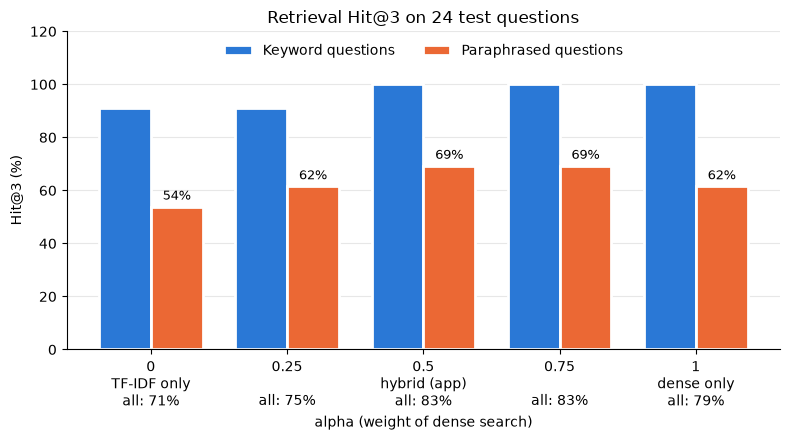

In [29]:
alpha_names = {0: "TF-IDF only", 0.25: "", 0.5: "hybrid (app)", 0.75: "", 1: "dense only"}

x_labels = []
for alpha in ALPHAS:
    x_labels.append(f"{alpha}\n{alpha_names[alpha]}\nall: {summary.loc[alpha, 'all']:.0f}%")

x = np.arange(len(ALPHAS))
bar_width = 0.38

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(x - bar_width / 2, summary["keyword"], bar_width, label="Keyword questions", color="#2a78d6", edgecolor="white", linewidth=2)
paraphrase_bars = ax.bar(x + bar_width / 2, summary["paraphrase"], bar_width,
                         label="Paraphrased questions", color="#eb6834", edgecolor="white", linewidth=2)
ax.bar_label(paraphrase_bars, fmt="%.0f%%", padding=3, fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(x_labels)
ax.set_xlabel("alpha (weight of dense search)")
ax.set_ylabel("Hit@3 (%)")
ax.set_ylim(0, 120)
ax.set_title(f"Retrieval Hit@3 on {len(eval_set)} test questions")
ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(loc="upper center", ncol=2, frameon=False)
plt.tight_layout()
plt.savefig(BASE_DIR / "assets" / "eval_hit_at_3.png", dpi=110)
plt.show()

### 8.2 Which questions does the app setting miss?
Looking at the failures tells us **why** retrieval fails, not only how often.

In [30]:
APP_ALPHA = 0.5

for item, row in zip(eval_set, rows):
    if not row[APP_ALPHA]:
        results = hybrid_search(item["question"], alpha=APP_ALPHA, top_k=3)
        retrieved_ids = [r["id"] for r in results]
        print("Q:", item["question"])
        print("   expected:", item["relevant"])
        print("   got:     ", retrieved_ids)
        print()

Q: How can I fine-tune a 7 billion parameter model on one graphics card?
   expected: ['Fine Tuning LLMs_p15']
   got:      ['Fine Tuning LLMs_p12', 'Fine Tuning LLMs_p43', 'Fine Tuning LLMs_p11']

Q: Which points are dense, which are on the edge and which are outliers in density-based clustering?
   expected: ['DBSCAN_p5', 'DBSCAN_p13', 'DBSCAN_p14']
   got:      ['DBSCAN_p1', 'DBSCAN_p2', 'DBSCAN_p6']

Q: How many neighbors should I look at when classifying a new point?
   expected: ['KNN_p25', 'KNN_p29', 'KNN_p31', 'KNN_p34', 'KNN_p41', 'KNN_p54', 'KNN_p60']
   got:      ['KNN_p11', 'DBSCAN_p5', 'DBSCAN_p4']

Q: Why do we shrink the feature maps inside a convolutional network?
   expected: ['intro to CV & CNN_p48']
   got:      ['intro to CV & CNN_p40', 'intro to CV & CNN_p30', 'intro to CV & CNN_p49']



### 8.3 Results and what they mean
| alpha | All (24) | Keyword (11) | Paraphrase (13) |
|---|---|---|---|
| 0 (TF-IDF only) | 70.8% | 90.9% | 53.8% |
| 0.25 | 75.0% | 90.9% | 61.5% |
| **0.5 (hybrid, used in the app)** | **83.3%** | **100%** | **69.2%** |
| 0.75 | 83.3% | 100% | 69.2% |
| 1 (dense only) | 79.2% | 100% | 61.5% |

**What we learn:**
1. **TF-IDF alone is the weakest (71%)**, and it fails mostly on paraphrased questions (54%):
   if the student says *"extreme values"* and the slide says *"outliers"*, there is no shared word to match.
2. **Dense alone (79%)** understands meaning, so it fixes most paraphrases,
   but it misses some questions that TF-IDF finds, e.g. the dropout question
   (the rare word *"neurons"* matches the Dropout slide exactly).
3. **Hybrid (0.5 and 0.75) is the best (83%)**: each method covers some mistakes of the other.
   → We **keep `alpha=0.5`** in the app. Now it is chosen by data, not by guess.

**Being honest about the numbers:**
- 24 questions is a **small** test set: one question = 4.2%. The difference between hybrid and dense only is **one question**.
  So the fair conclusion is "hybrid is at least as good as dense, and clearly better than TF-IDF alone", not "hybrid is 4% better".
- 0.5 and 0.75 tie; we keep 0.5 (no reason to change a setting that the data does not prefer).
- While checking the misses we found one **labeling mistake of ours**: the gradient boosting question is also answered by
  `decision tree & ensemble learning_p73` and `_p79` (*"each new tree uses the residual of the prior tree as the target"*).
  We added them to `relevant`. A test set written by one person can miss correct slides.

**Why the remaining questions fail (at alpha = 0.5):**
- **Title slides win:** for the CNN question the top result is the section title *"CNN Hyperparameters ... Part 9–13"*, not the Pooling slide.
  Title slides have few words, so the few words they have get high scores.
- **Hard paraphrases:** *"one graphics card"* vs the slide's *"single modern GPU"*; *"on the edge / outliers"* vs *"border / noise"*.
- **Defining vs choosing:** for *"How many neighbors should I look at?"* the search returns the slide that **defines** K, not the slides about **choosing** K.

**Possible improvements (future work):** skip very short title slides, add a re-ranker, and test with more questions.

## 9. End-to-end evaluation on the answered HCIA bank
Section 8 only checked **retrieval** (is the right slide in the top 3?).
Now we have the bank's **answer key**, so we can test the **whole pipeline**: retrieval + LLM → is the final answer correct?

For each bank question:
1. `hybrid_search` finds the 3 best slides (same settings as the app: `alpha=0.5`, `top_k=3`)
2. The LLM answers the MCQ **only from those slides**, or says the slides do not cover it
3. We compare with the answer key

Every question ends in one of 3 groups:
| Group | Meaning |
|---|---|
| **Correct** | answered from the slides, same letter(s) as the key |
| **Wrong** | answered from the slides, different letter(s) |
| **Not in lectures** | the slides do not cover it → the student needs other sources for this topic |

This also answers a useful question for the student: **which HCIA topics are not covered by our NTI lectures?**

### 9.1 Load the answer key (and clean it)
The key is a separate Word file with the same questions, plus a line `Answer: B` or `Answer: A, B, D` after each one.
While parsing it we found **problems in the key itself**, so the code checks for them instead of trusting the file:
- some questions have **extra `Answer:` lines** (a second or third one) → we keep the **first** one, which is the one right under the options
- a question whose number of answers does not fit its type (single-choice with 3 letters) → **excluded** from the evaluation

In [31]:
ANSWER_KEY_DOCX = BASE_DIR / "question_bank_answer_key.docx"

key_doc = Document(ANSWER_KEY_DOCX)
answer_key = {}           # bank id → list of correct letters
extra_answer_lines = []   # "Answer:" lines found after the first one of the same question
current_id = None

for paragraph in key_doc.paragraphs:
    text = paragraph.text.strip()

    question_match = re.match(r"^(\d+)\.\s*\[(.+?)\]", text)
    if question_match:
        current_id = f"bank_{question_match.group(1)}"
        continue

    answer_match = re.match(r"^Answer:\s*(.+)$", text)
    if answer_match and current_id is not None:
        letters = []
        for letter in answer_match.group(1).split(","):
            letters.append(letter.strip())

        if current_id in answer_key:
            extra_answer_lines.append((current_id, letters))
        else:
            answer_key[current_id] = letters

print("Questions with an answer:", len(answer_key), "/", len(bank))
print("Extra 'Answer:' lines (ignored):", extra_answer_lines)

# ---------- Keep only questions whose answer fits their type ----------
eval_bank = []
excluded = []
for q in bank:
    key = answer_key.get(q["id"])
    if key is None:
        excluded.append((q["id"], "no answer in the key"))
    elif q["type"] == "single" and len(key) != 1:
        excluded.append((q["id"], f"single-choice but the key says {key}"))
    elif q["type"] == "multiple" and len(key) < 2:
        excluded.append((q["id"], f"multiple-choice but the key says {key}"))
    else:
        eval_bank.append(q)

print("Excluded:", excluded)
print("Questions we evaluate:", len(eval_bank))

Questions with an answer: 130 / 130
Extra 'Answer:' lines (ignored): [('bank_11', ['B', 'C', 'D']), ('bank_96', ['B']), ('bank_96', ['A', 'B', 'C', 'D']), ('bank_103', ['B'])]
Excluded: [('bank_12', "single-choice but the key says ['A', 'C', 'D']")]
Questions we evaluate: 129


### 9.2 Answer one bank question with RAG
- **Search query = question + its 4 options.** Many bank questions start with *"Which of the following…"*: the question alone has almost no topic words, the options do.
- **JSON mode, temperature 0:** we need the letters as data to grade them, and the same answer every run.
- **Grounding check:** the LLM must name one of the 3 slide ids it was given (`clean_source` from Section 7.3).
  An answer with no valid source is **not** counted as answered from the lectures: it probably came from the LLM's own knowledge.

In [32]:
bank_llm = ChatOpenAI(model=LLM_NAME, temperature=0).bind(response_format={"type": "json_object"})


def build_bank_prompt(q, retrieved_chunks):
    slide_parts = []
    for c in retrieved_chunks:
        slide_parts.append(f"[slide id: {c['id']}]\n{c['text']}")
    slides = "\n\n---\n\n".join(slide_parts)

    option_lines = []
    for letter, option_text in q["options"].items():
        option_lines.append(f"{letter}. {option_text}")
    options = "\n".join(option_lines)

    if q["type"] == "single":
        rule = "Exactly ONE option is correct."
    else:
        rule = "One or MORE options are correct (select all that apply)."

    return f"""You answer an exam question using ONLY the lecture slides below.

Slides:
{slides}

Question ({rule})
{q['question']}
{options}

Rules:
1. Use only the slides. Do not use outside knowledge.
2. If the slides do not contain enough information to answer, reply with "in_lectures": false and "answer": [].
3. Otherwise reply with "in_lectures": true, the correct letter(s), and the id of the slide you used.

Reply in JSON only, like this:
{{"in_lectures": true, "answer": ["B"], "source": "one of the slide ids above"}}"""


def answer_bank_question(q):
    options_text = " ".join(q["options"].values())
    retrieved = hybrid_search(q["question"] + " " + options_text, alpha=0.5, top_k=3)
    retrieved_ids = [c["id"] for c in retrieved]

    response = bank_llm.invoke(build_bank_prompt(q, retrieved))
    try:
        data = json.loads(response.content)
    except json.JSONDecodeError:
        data = {}

    in_lectures = data.get("in_lectures") is True
    answer = data.get("answer")
    if not isinstance(answer, list):
        answer = []
    source = clean_source(data.get("source"))

    # Grade
    key = answer_key[q["id"]]
    if not in_lectures or source not in retrieved_ids:
        status = "not in lectures"
    elif set(answer) == set(key):
        status = "correct"
    else:
        status = "wrong"

    return {
        "id": q["id"],
        "section": q["section"],
        "type": q["type"],
        "question": q["question"],
        "key": key,
        "predicted": answer,
        "source": source,
        "retrieved": retrieved_ids,
        "status": status,
    }


# ---------- Test on one question ----------
print(json.dumps(answer_bank_question(eval_bank[0]), indent=2))

{
  "id": "bank_1",
  "section": "AI Fundamentals & Applications",
  "type": "single",
  "question": "In a typical AI technology stack (data, compute/infrastructure, algorithms, applications), which layer is primarily responsible for providing hardware resources such as AI accelerator chips?",
  "key": [
    "B"
  ],
  "predicted": [],
  "source": null,
  "retrieved": [
    "DeepLearning_p22",
    "intro to CV & CNN_p31",
    "DeepLearning_p16"
  ],
  "status": "not in lectures"
}


### 9.3 Run it on the whole bank
~130 LLM calls (gpt-4o-mini, a few minutes, a few cents). The results are **saved** to `bank_eval_results.json`,
so "Restart & Run All" does not call the LLM again. Set `RERUN_BANK_EVAL = True` to run it again.

In [33]:
BANK_EVAL_JSON = BASE_DIR / "bank_eval_results.json"
RERUN_BANK_EVAL = False

if BANK_EVAL_JSON.exists() and not RERUN_BANK_EVAL:
    with open(BANK_EVAL_JSON, encoding="utf-8") as f:
        bank_results = json.load(f)
    print("Loaded saved results:", len(bank_results))
else:
    bank_results = []
    for i, q in enumerate(eval_bank, start=1):
        bank_results.append(answer_bank_question(q))
        if i % 10 == 0:
            print(f"{i} / {len(eval_bank)} done")
    with open(BANK_EVAL_JSON, "w", encoding="utf-8") as f:
        json.dump(bank_results, f, ensure_ascii=False, indent=2)
    print("Saved →", BANK_EVAL_JSON.name)

results_df = pd.DataFrame(bank_results)
counts = results_df["status"].value_counts()
answered = counts.get("correct", 0) + counts.get("wrong", 0)

print()
print(counts)
print(f"\nCovered by the lectures: {answered} / {len(results_df)} = {answered / len(results_df):.0%}")
print(f"Accuracy when answered:  {counts.get('correct', 0)} / {answered} = {counts.get('correct', 0) / max(answered, 1):.0%}")
print(f"Accuracy on all:         {counts.get('correct', 0)} / {len(results_df)} = {counts.get('correct', 0) / len(results_df):.0%}")

10 / 129 done
20 / 129 done
30 / 129 done
40 / 129 done
50 / 129 done
60 / 129 done
70 / 129 done
80 / 129 done
90 / 129 done
100 / 129 done
110 / 129 done
120 / 129 done
Saved → bank_eval_results.json

status
correct            76
not in lectures    44
wrong               9
Name: count, dtype: int64

Covered by the lectures: 85 / 129 = 66%
Accuracy when answered:  76 / 85 = 89%
Accuracy on all:         76 / 129 = 59%


**Two numbers, two meanings:**
- **Covered by the lectures** = how much of the HCIA bank our NTI slides can answer at all (a property of the **data**)
- **Accuracy when answered** = when the slides do cover a question, how often our pipeline gets it right (a property of **our system**)

Accuracy on all questions mixes both, so on its own it would blame the system for topics that are simply not in the slides.

In [34]:
STATUS_ORDER = ["correct", "wrong", "not in lectures"]

section_table = pd.crosstab(results_df["section"], results_df["status"])
for status in STATUS_ORDER:
    if status not in section_table.columns:
        section_table[status] = 0
section_table = section_table[STATUS_ORDER]
section_table["questions"] = section_table[STATUS_ORDER].sum(axis=1)
section_table["covered_%"] = ((section_table["correct"] + section_table["wrong"]) / section_table["questions"] * 100).round()
section_table["accuracy_when_answered_%"] = (
    section_table["correct"] / (section_table["correct"] + section_table["wrong"]).replace(0, np.nan) * 100
).round()
section_table = section_table.sort_values("covered_%", ascending=False)
section_table

status,correct,wrong,not in lectures,questions,covered_%,accuracy_when_answered_%
section,,,,,,
CNNs & Computer Vision,10,2,0,12,100.0,83.0
Data Preprocessing & Evaluation,8,3,1,12,92.0,73.0
"NLP, Transformer & Attention",11,0,1,12,92.0,100.0
Neural Networks & Activation Functions,12,0,3,15,80.0,100.0
"Training, Optimization & Regularization",10,0,3,13,77.0,100.0
AI Fundamentals & Applications,9,0,3,12,75.0,100.0
Machine Learning Basics,7,1,4,12,67.0,88.0
Large Models & Fine-Tuning,6,2,7,15,53.0,75.0
Frameworks & Tools,2,1,11,14,21.0,67.0


**Chart:** what happened to the bank questions of each section.
- **X-axis:** % of the section's questions · **Y-axis:** bank section
- **Blue** = correct, **orange** = wrong, **gray** = not in our lectures
- **Look for:** long gray bars = HCIA topics the student must study from **other sources**; orange = real mistakes of our system.

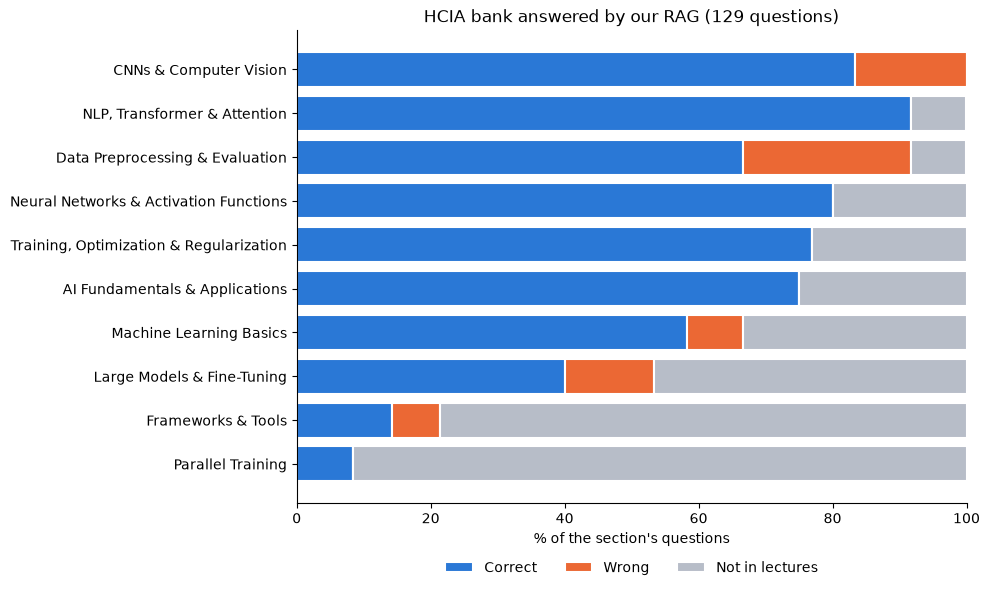

In [35]:
plot_table = section_table.sort_values("covered_%")
percent = plot_table[STATUS_ORDER].div(plot_table["questions"], axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 6))
left = np.zeros(len(percent))
colors = {"correct": "#2A78D6", "wrong": "#EB6834", "not in lectures": "#B7BDC8"}
for status in STATUS_ORDER:
    ax.barh(percent.index, percent[status], left=left, color=colors[status],
            label=status.capitalize(), edgecolor="white", linewidth=1.5)
    left = left + percent[status].values

ax.set_xlabel("% of the section's questions")
ax.set_xlim(0, 100)
ax.set_title(f"HCIA bank answered by our RAG ({len(results_df)} questions)")
ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.18), ncol=3, frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(BASE_DIR / "assets" / "bank_eval.png", dpi=160)
plt.show()

### 9.4 Look at the mistakes
Read the wrong answers yourself: is the key right? Did retrieval bring the wrong slides? Did the LLM misread a slide?
This tells us which part of the pipeline to improve.

In [36]:
wrong = results_df[results_df["status"] == "wrong"]
print("Wrong answers:", len(wrong))
for _, row in wrong.iterrows():
    print(f"\n{row['id']} ({row['type']}) {row['question'][:100]}")
    print(f"   key: {row['key']}   predicted: {row['predicted']}   source: {row['source']}")
    print(f"   retrieved: {row['retrieved']}")

Wrong answers: 9

bank_17 (multiple) Which of the following are common ensemble learning methods?
   key: ['A', 'B', 'D']   predicted: ['B', 'D']   source: decision tree & ensemble learning_p95
   retrieved: ['decision tree & ensemble learning_p74', 'decision tree & ensemble learning_p67', 'decision tree & ensemble learning_p95']

bank_59 (single) If a 64×64 image is input and a 3×3 kernel is used for convolution with a stride of 1, what is the s
   key: ['B']   predicted: ['A']   source: intro to CV & CNN_p43
   retrieved: ['Generative AI & Diffusion models_p42', 'Generative AI & Diffusion models_p43', 'intro to CV & CNN_p43']

bank_63 (multiple) Which of the following are common data augmentation techniques used specifically for image data?
   key: ['A', 'B', 'D']   predicted: ['A', 'B']   source: intro to CV & CNN_p26
   retrieved: ['intro to CV & CNN_p26', 'intro to CV & CNN_p25', 'Word Embedding_p15']

bank_78 (multiple) Which of the following are commonly used Python libraries fo

**Results (final run, 129 questions):**
| | Count | % |
|---|---|---|
| Correct | 76 | 59% |
| Wrong | 9 | 7% |
| Not in lectures | 44 | 34% |

- **Covered by the lectures: 85 / 129 = 66%.** *Parallel Training* (8%) and *Frameworks & Tools* (21%) are almost not in the NTI lectures, *Large Models & Fine-Tuning* only half (53%).
  For these topics the student needs other sources. *CNNs & Computer Vision* is fully covered (100%).
- **Accuracy when answered: 76 / 85 = 89%.** This is the number that measures **our system**.
- **Single vs multiple choice:** single-choice 63 / 64 correct (98%), multiple-choice 13 / 21 (62%).
  8 of the 9 wrong answers are multiple-choice, and 7 of them **miss one correct option**: the 3 slides mention some options but not all,
  and the model (correctly, by our rule) does not pick what it cannot find in the slides. The other one picks too many (bank_93).
- The only wrong single-choice answer (bank_59) needs a **calculation** (conv output size), not a fact from a slide.


---
## 10. Summary
| Step | Result |
|---|---|
| EDA | 24 PDFs checked → 2 excluded (exact duplicate, image-only), screenshot pages = known limitation |
| Chunking | 1,015 pages → **887** chunks (100 empty, 28 duplicate pages skipped), 0 truncated |
| Retrieval (Section 8) | Hit@3: hybrid **83%** vs dense 79% vs TF-IDF 71% → `alpha=0.5` kept |
| Whole pipeline (Section 9) | HCIA bank: **66%** covered by the lectures, **89%** correct when answered |

**Limitations:** text inside screenshots is not extracted · English only (`bge-small-en`) · small retrieval test set (24) ·
multiple-choice questions are harder (62% vs 98% single) · some HCIA topics (Parallel Training, Frameworks & Tools) are not in the lectures.

**Future work:** vision LLM for screenshot pages · multilingual embeddings · re-ranker / skip title slides · more slides (`top_k`) for multiple-choice questions.


---
## Appendix: first experiment, Agentic chunking (not used)
We first tried agentic chunking on `Fine_Tuning_LLMs.pdf` → 26 chunks, avg ~1000 chars.
We replaced it with page-based chunking because it loses page numbers and needs one API call per paragraph
(too slow and costly for 22 PDFs). Kept here for the comparison in the presentation.
Set `RUN_AGENTIC_CHUNKING = True` only if you want to re-run it.

In [37]:
RUN_AGENTIC_CHUNKING = False


def agentic_chunking(text, llm, max_chars=2000):
    paragraphs = [p.strip() for p in text.split("\n\n") if p.strip()]

    chunks = []
    current_chunk = ""

    for paragraph in paragraphs:
        prompt = f"""
You are a document chunking agent.

Current chunk:
{current_chunk}

New paragraph:
{paragraph}

Should the new paragraph belong to the current chunk?

Answer ONLY:
YES
or
NO
"""
        decision = llm.invoke(prompt).content.strip().upper()

        if decision == "YES" and len(current_chunk) + len(paragraph) <= max_chars:
            current_chunk += "\n\n" + paragraph
        else:
            if current_chunk:
                chunks.append(current_chunk)
            current_chunk = paragraph

    if current_chunk:
        chunks.append(current_chunk)

    return chunks


if RUN_AGENTIC_CHUNKING:
    ft_pages = get_pages_text(LECTURES_DIR / "Fine_Tuning_LLMs.pdf")
    ft_document = "\n\n".join(p for p in ft_pages if p)
    agentic_chunks = agentic_chunking(ft_document, ChatOpenAI(model=LLM_NAME, temperature=0))
    lengths = [len(c) for c in agentic_chunks]
    print("Chunks:", len(agentic_chunks), "| avg chars:", sum(lengths) / len(lengths))
else:
    print("Skipped (agentic chunking is not part of the final pipeline)")

Skipped (agentic chunking is not part of the final pipeline)
